In [1]:
from integrated_gradients.integrated_gradients import compute_integrated_gradients
from model.resnet50_utils import make_predictions_and_gradients
from PIL import Image
import torch
import numpy as np
from torchvision.transforms import PILToTensor

In [2]:
# make_predictions_and_gradients([Image.open("..\\Images\\1bd6987fa9219dec.jpg").convert("RGB")], 0)

num_steps = 25
input_tensor = PILToTensor()(Image.open("Images\\weimaraner-1381186_1920c6aeb.jpg").convert("RGB").resize((224,224))) 
gradients, preds = compute_integrated_gradients(input_tensor, 0, make_predictions_and_gradients, None, num_steps)

26


c:\Users\Oswin\miniconda3\envs\XAIenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Oswin\miniconda3\envs\XAIenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


torch.Size([26])
torch.Size([26, 3, 224, 224])
torch.Size([26, 3, 224, 224])


In [3]:
import urllib.request

url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = urllib.request.urlopen(url).read().decode("utf-8").split("\n")

In [4]:
print(preds.shape)
max_class = torch.argmax(preds[num_steps])
print(max_class)
print(labels[max_class])

pred = torch.tensor(preds[-1])

top5 = torch.argsort(pred, descending=True)[:5]

for idx in top5:
    print(idx.item(), labels[idx.item()], pred[idx].item())

print(input_tensor.shape)
print(gradients.shape)

torch.Size([26, 1000])
tensor(818)
spotlight
818 spotlight 1.0
1 goldfish 0.0
2 great white shark 0.0
3 tiger shark 0.0
4 hammerhead 0.0
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


C:\Users\Oswin\AppData\Local\Temp\ipykernel_14276\2320976922.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred = torch.tensor(preds[-1])


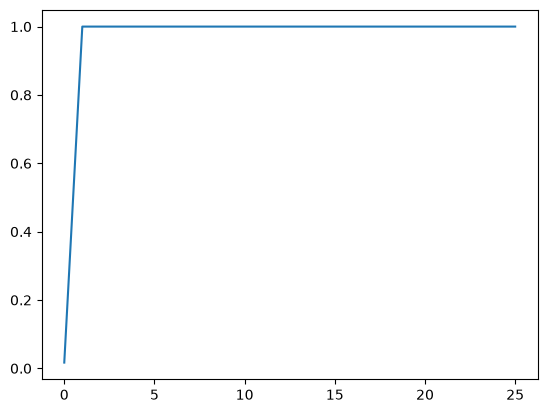

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(range(num_steps+1), preds.detach().numpy()[:,max_class])
plt.show()